# Steel Thread — Isolating the Effect of Interventions on Item Warm-Up

This notebook builds a controlled experiment for measuring how a recommender's ability to
retrieve an item changes as that item accumulates its own interaction history — and it's
built specifically so that later interventions (content embeddings, improved content
embeddings, LLM-simulated interactions) can be added and compared on equal footing.

**The core experimental principle:** hold every source of variation fixed except the one
under study. User preferences are fit once, frozen, and reused identically everywhere in
this notebook — for the baseline pure-CF method and for every future method this
experiment gets extended to. Only the *item's* representation is allowed to change as it
gains interaction history. This means an observed change in retrieval quality can be
attributed to "this item gained more signal," not to "the model also happened to relearn
different user preferences this time."

**Dataset:** Amazon Books 5-core, restricted to common users (users who reviewed both Books and
Movies) — see data_filtering.ipynb's "Build the 5-core enriched dataset" section. The full-scale run.

**Runtime:** dual RTX 4090 (WSL2/CUDA). `implicit` does `fit()` + `recalculate_item()` on CPU;
retrieval/top-K (`recommend`) runs on the GPU via `cf.ALSModel.prepare_gpu_recommend` (torch.topk).

---
## Module layout

The pipeline logic itself now lives in four importable modules, not in this notebook:

- **`load.py`** — load the Amazon Books reviews, ID remapping, the cold/warm split, and the
  warm-item reference train/test split. Returns one `Dataset` object.
- **`protocol.py`** — `RetrievalModel`, the structural contract (`fit`/`recommend`/`fold_in`)
  every retrieval method below satisfies, so `eval.py` never branches on model type.
- **`pop.py`** — `PopularityModel` (Section 5a) and `ActivityModel`, its Mode-B dual.
- **`cf.py`** — `ALSModel` (Section 5b), wrapping `implicit`'s ALS.
- **`eval.py`** — every metric function, the within-item ceiling reference, and both warm-up
  sweeps (Mode A: user-centric via `sweep_mode_a_cached`; Mode B: item-to-user via
  `sweep_item_to_user_gpu`) — one call per method, no hand-written per-model loop.

A future intervention (a content-based hybrid method, say) becomes a new module implementing
`RetrievalModel` — plugging into `eval.py` with no changes to `eval.py` itself.

### Note on the `implicit` API
This notebook targets **`implicit` 0.7.x**. `model.fit()`, `ndcg_at_k()`, and
`model.recommend()` all expect a **user × item** matrix; we build and use one consistently
throughout. `AlternatingLeastSquares.recalculate_item(itemid, item_users)` is the one
exception — it expects **item × user** orientation. This is handled once, inside
`Dataset.revealed_item_users_at_k()` and `cf.ALSModel.fold_in()`, rather than at every call
site as before.

## 0. Environment & imports

In [ ]:
%%time
import platform
import sys
import time

sys.path.insert(0, "..")  # notebook lives in notebooks/; the recsys/ package is one level up

import numpy as np
import matplotlib
try:
    get_ipython()            # defined only under IPython/Jupyter -> keep the inline backend
except NameError:
    matplotlib.use("Agg")    # plain `python script.py`: headless, save figures to PNG instead
import matplotlib.pyplot as plt
import implicit
import wandb

from recsys import load
from recsys import pop
from recsys import cf
from recsys import content
from recsys import cbhcf
from recsys import intervention_a as ia
from recsys import eval as ev

DEVICE = "cuda:1"   # which GPU the recommend/sweeps use. GPU 1 is idle; GPU 0 is shared with the
                    # desktop (and gets starved). ALS fit() is CPU-only regardless (no GPU implicit).

print(f"python     {platform.python_version()}  ({platform.machine()})")
print(f"implicit   {implicit.__version__}")

# Weights & Biases (W&B) -- experiment tracking for the warm-up sweeps (Sections 9-10).
WANDB_ENTITY_NAME = "mads-team-cold-start"
WANDB_PROJECT_NAME = "llm-cold-start-recsys"
RUN_TAG = time.strftime("%Y%m%d-%H%M%S")

WANDB_ENABLED = False   # flip to False for a local run (disabled = no-op, nothing uploaded)
WANDB_MODE = "online" if WANDB_ENABLED else "disabled"

/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of '/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/_cuda.so: undefined symbol: _ZN3rmm13device_bufferC1EmNS_16cuda_stream_viewENS_6detail23cccl_async_resource_refIN4cuda2mr3__412resource_refIJNS6_17device_accessibleEEEEEE'
  warnings.warn(


python     3.12.13  (x86_64)
implicit   0.7.3
CPU times: user 2.15 s, sys: 1.35 s, total: 3.5 s
Wall time: 2.22 s


## 1-4. Load Amazon Books, build the cold/warm split

See `load.py` for the full mechanism (ID remapping, sparse matrix construction, the cold-item
eligibility filter and reveal/reserve split, and the warm-item reference split). Briefly:

- A fixed 10% of items with at least 25 total interactions are selected as structurally
  "cold" (`load.load_dataset`'s defaults: `min_interactions=25`, `cold_item_fraction=0.10`).
- Each cold item's first 20 interactions (chronologically) form its revealable history —
  `Dataset.revealed_matrix_at_k(k)`/`revealed_item_users_at_k(k)` expose exactly the first
  `k` of these; everything after is permanently reserved for evaluation (`Dataset.test_matrix`).
- A per-user leave-last-out (LOO) split on the warm (non-cold) items gives `Dataset.ref_train`/
  `ref_val`/`ref_test` — each user's last warm interaction is held out for test, the second-last
  for val, the rest for train. Every model in this notebook fits on `ref_train`, so no model has
  ever seen a single cold-item interaction.

In [2]:
%%time
# Pickle cache for static, expensive-to-rebuild results (the Dataset; the Popularity floor).
# cache_pickle keys each file by name + a short hash of `params` (K, K_LEVELS, ...), so changing a
# parameter automatically uses a fresh cache file instead of a stale one. It does NOT track recsys
# code changes -- if you edit load.py's split or an eval.py metric, clear data/cache/ by hand.
import os
import pickle
import hashlib


def cache_pickle(name, compute, params=None):
    tag = "" if params is None else "_" + hashlib.md5(repr(params).encode()).hexdigest()[:8]
    path = f"../data/cache/{name}{tag}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    val = compute()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(val, f, protocol=pickle.HIGHEST_PROTOCOL)
    return val


# Cache keys are FINGERPRINTS, not fixed names. The Dataset is keyed on its INPUTS
# (load.load_params_fingerprint: the parquet's name/size/mtime plus every split argument), because
# you would have to build the Dataset to compute anything about its contents. Everything downstream
# is keyed on the OUTPUT (load.dataset_fingerprint: user/item counts, ref_train/ref_val/ref_test
# nnz, and the size AND id-sum of both cold populations). Between the two, changing the split -- or
# the source file -- silently reusing a stale artifact is impossible rather than merely unlikely.
# Neither tracks recsys *code* changes: clear ../data/cache/ by hand if you edit a metric or the
# content field map.
DATA_PATH = "../data/filtered/books_5core_common.parquet"
SPLIT_PARAMS = dict(cold_item_fraction=0.10, cold_val_fraction=0.10)

dataset = cache_pickle("books_dataset", lambda: load.load_dataset(data_path=DATA_PATH, **SPLIT_PARAMS),
                       params=load.load_params_fingerprint(DATA_PATH, **SPLIT_PARAMS))
FP = load.dataset_fingerprint(dataset)   # every downstream cache key includes this

N_REVEAL = 20
K_LEVELS = list(range(N_REVEAL + 1))  # 0, 1, 2, ..., 20

print(f"users: {dataset.n_users:,}   items: {dataset.n_items:,}")
print(f"cold items (test): {len(dataset.cold_item_ids):,}"
      + (f"   cold items (validation): {len(dataset.cold_val.cold_item_ids):,}"
         if dataset.cold_val is not None else "   (no validation cold set)"))
print(f"ref_train non-zeros: {dataset.ref_train.nnz:,}   ref_test non-zeros: {dataset.ref_test.nnz:,}")
print(f"reserved cold-item test interactions: {dataset.test_matrix.nnz:,}")
print(f"dataset fingerprint: {FP}")

users: 384,339   items: 487,790
cold items (test): 2,727   cold items (validation): 2,727
ref_train non-zeros: 2,676,601   ref_test non-zeros: 345,998
reserved cold-item test interactions: 13,635
dataset fingerprint: (384339, 487790, 2676601, 345998, 347561, 2727, 633483902, 13635, 2727, 625156242)
CPU times: user 55.9 ms, sys: 155 ms, total: 211 ms
Wall time: 216 ms


## 5. Two retrieval models — popularity baseline and collaborative filtering

This is the point in the pipeline where different retrieval **methods** are compared, side
by side, against the exact same data — 5a is a no-collaborative-filtering floor, 5b is the
collaborative-filtering method under study today. A future intervention becomes a third
`RetrievalModel` implementation here, not a restructuring of this notebook.

**Both models fit on `dataset.ref_train`** — nothing else, and this matters. It contains only
warm items, so the resulting user representations have never seen a single cold item's
interaction, at any point.

### 5a. Popularity baseline (no collaborative filtering)

Ranks items by raw training-interaction count — the same global list for every user,
personalized only by excluding each user's already-seen items. See `pop.PopularityModel`.

In [3]:
%%time
pop_model = pop.PopularityModel().fit(dataset.ref_train)
print(f"Most popular item (train_index {pop_model.ranked_items[0]}): "
      f"{pop_model.popularity[pop_model.ranked_items[0]]} training interactions")

Most popular item (train_index 441091): 3272 training interactions
CPU times: user 27.3 ms, sys: 11.5 ms, total: 38.8 ms
Wall time: 38.7 ms


### 5b. Collaborative filtering — ALS

`implicit.als.AlternatingLeastSquares`, wrapped by `cf.ALSModel` to satisfy
`protocol.RetrievalModel`. This fits one ALS model at the real baseline config (below); it is
**reused as seed 0** of Section 6's `N_SEEDS` ensemble (so no fit is wasted) and is also the
example model for Section 8's per-user recommendations. ALS fit is CPU-bound and scales with
factors^2 * iterations; the GPU recommend/sweep are unaffected by raising them.

In [4]:
%%time
# Real config for a fair baseline (Option B: CPU fit -- conda-forge implicit has no GPU build).
# ALS fit() is CPU-bound and scales ~O(nnz * factors^2 * iterations), so at ~5M interactions this
# is SLOW -- expect a long fit per model (N_SEEDS is dropped below to bound total fit time). The
# GPU recommend/sweeps are unaffected by the larger factors.
# Model hyperparameters, declared here because ALS_PARAMS (below) consumes them and is defined
# before Section 6's N_SEEDS. N_ITERATIONS is the ALS training-iteration count; both `model` (5b)
# and the N_SEEDS ensemble (Section 6) fit with these exact params.
N_FACTORS = 64
N_ITERATIONS = 20   # final baseline run (was 15 for dev). More iters -> more converged factors.
ALS_PARAMS = dict(factors=N_FACTORS, regularization=0.01, iterations=N_ITERATIONS)

# Cached by (dataset fingerprint, ALS params, seed). ALS fit is the single most expensive step in
# this notebook and it is perfectly reproducible -- same ref_train, same params, same random_state
# gives the same factors -- so there is no reason to pay for it twice. The fingerprint in the key is
# what makes that safe: change the split and these files are simply not found.
def _fit_als(seed):
    m = cf.ALSModel(random_state=seed, **ALS_PARAMS)
    print(f"Fitting ALS seed {seed} on the reference training set...", flush=True)
    m.fit(dataset.ref_train)
    return m


model = cache_pickle("als_seed0", lambda: _fit_als(0),
                     params=(FP, tuple(sorted(ALS_PARAMS.items()))))   # reused as seed 0 below
print("Done.")

Done.
CPU times: user 0 ns, sys: 235 ms, total: 235 ms
Wall time: 244 ms


### 5c. Content-based hybrid — CBHCF (the first intervention)

The first method that is *not* pure collaborative filtering, and the template for the
interventions after it. CBHCF **adds** a content score to ALS's collaborative score:

> `score(u, i) = cf(u, i) / s_cf  +  lambda · content(u, i) / s_cb`

**Content is permanent, and the handoff is automatic rather than scheduled.** At `k = 0` a cold
item's ALS fold-in factor is the exact zero vector (Section 7 verifies this), so `cf(u, i) = 0`
and the item is ranked on content alone. As it accumulates interactions the collaborative term
grows on its own and comes to dominate. There is no threshold and no per-item weight — the single
free parameter is `lambda`.

This matches what the literature actually does (see `citations.md` §4): CTR/CDL set an item's
latent vector to `v_j = theta_j + eps_j` — content plus a collaborative offset, with content
structurally permanent; DropoutNet keeps the content pathway forever and drops out the
*preference* input instead; feature-based production hybrids carry content at every degree. An
earlier draft of this section annealed content away past a fixed interaction count, which no cited
method does.

**Scaling is multiplicative only, never an offset.** `s_cf`/`s_cb` equalize the two terms' spread.
Subtracting a minimum (as a min-max normalization would) maps a zero collaborative score to a
positive constant, handing every cold item a spurious collaborative bonus and destroying the
property above. Both scales are measured once and held fixed across all reveal levels.

**This wraps the ALS fits, it does not replace them.** Every CBHCF model reuses one of Section 6's
ALS seeds unchanged, so the ALS→CBHCF gap is attributable to the content term and nothing else.

**Content representation** (`content.py`). Item text is built from five *roles* — title, creator,
taxonomy, blurb, reviews — mapped onto Books' columns (creator is `author_name` falling back to
`store`; `subtitle` is deliberately excluded, being the edition string, e.g. "Kindle Edition").
Each role is vectorized separately, L2-normalized, weighted and concatenated (BM25F), so a
3,000-word review block cannot drown an 8-word title and the author surname "Price" cannot collide
with the noun `price`. The vectorizer is fit on **warm items only** and applied to cold items with
the vocabulary frozen — the faithful simulation of a new item arriving at a deployed system.

**Why this is tractable at 487,790 items.** `content.py` guarantees row-L2-normalized vectors, so
`cosine_similarity(T) == T @ T.T` and the content score factors as `(history @ T) @ T[items].T` —
the ~950 GB item-item similarity matrix never exists. And because the user profile is frozen on
`ref_train`, the content scores depend on neither the reveal level nor the ALS seed nor lambda, so they
are computed **once per run**, cached to disk, and replayed everywhere.

In [5]:
%%time
import json

RUN_CBHCF = True            # False reproduces the pure-baseline run
RUN_IA = True               # Intervention A -- sentence embeddings for the item's own prose
CONTENT_CACHE_GPU = DEVICE  # build the Mode A content block with cuSPARSE SpMM (18x vs CPU)

# NOTHING here is chosen on this notebook's data. Field weights AND lambda for BOTH arms come from
# ../outputs/hyperparams.json["steel_thread_config"], selected on the cold-item VALIDATION
# population by notebooks/intervention_a_weight_sweep.ipynb -- which swept both arms over an
# IDENTICAL grid, so neither has a tuning advantage over the other. Choosing any of it on the test
# cold set would bias every number below. The artifact carries the fingerprint it was tuned against
# and we refuse it against a different split.
#
# This supersedes the earlier lambda-only selection (hyperparameter_tuning.ipynb, which left field
# weights at content.DEFAULT_WEIGHTS). That record is still in hyperparams.json under "cbhcf" for
# provenance; only `reviews` differs (0.5 -> 1.0), and lambda moves 2 -> 3.
CBHCF_LAMBDA_FALLBACK = 1.0   # used only if no artifact exists (lambda=1 == equal spread contribution)


def load_steel_config():
    path = "../outputs/hyperparams.json"
    if not os.path.exists(path):
        print(f"No {path}; falling back to UNTUNED defaults -- run "
              f"intervention_a_weight_sweep.ipynb for selected values.")
        return None
    with open(path) as f:
        rec = json.load(f).get("steel_thread_config")
    if rec is None:
        print(f"{path} has no steel_thread_config; run intervention_a_weight_sweep.ipynb.")
        return None
    if tuple(rec["dataset_fingerprint"]) != FP:
        raise RuntimeError(
            f"{path} steel_thread_config was tuned on a different split -- refusing to use it. "
            f"artifact fingerprint {tuple(rec['dataset_fingerprint'])}, current {FP}. "
            f"Re-run intervention_a_weight_sweep.ipynb, or delete the section to fall back "
            f"to untuned defaults.")
    return rec


STEEL_CFG = load_steel_config()
if STEEL_CFG is None:
    CBHCF_FIELD_WEIGHTS, CBHCF_LAMBDA = None, CBHCF_LAMBDA_FALLBACK
    CBHCF_LAMBDA_PROVENANCE = "untuned fallback"
    IA_CFG = None
else:
    CBHCF_FIELD_WEIGHTS = STEEL_CFG["cbhcf"]["field_weights"]
    CBHCF_LAMBDA = float(STEEL_CFG["cbhcf"]["content_weight"])
    CBHCF_LAMBDA_PROVENANCE = STEEL_CFG["selected_on"]
    IA_CFG = STEEL_CFG["intervention_a"]
RUN_IA = RUN_IA and IA_CFG is not None

if RUN_CBHCF:
    print(f"CBHCF          lambda={CBHCF_LAMBDA}  field_weights={CBHCF_FIELD_WEIGHTS}")
if RUN_IA:
    print(f"Intervention A {IA_CFG['model_key']}  lambda={IA_CFG['content_weight']}  "
          f"text_w={IA_CFG['text_weight']}  description={IA_CFG['description_mode']}"
          f"@{IA_CFG['description_weight']}")
    print(f"  cold_val objectives -- CBHCF {STEEL_CFG['cbhcf']['coldval_objective']:.5f}   "
          f"Intervention A {IA_CFG['coldval_objective']:.5f}")
print(f"  selected on: {CBHCF_LAMBDA_PROVENANCE}")

# The item x term matrix is expensive to build (a ~1 GB metadata parquet, then a fit + transform
# over 487,790 documents, ~4 min) and depends only on the metadata file, the field map and the WARM
# item set -- so it is keyed by the dataset fingerprint and cached.
warm_item_ids = np.unique(dataset.ref_train.nonzero()[1])


def _content_matrix():
    docs = content.load_item_documents(
        "../data/filtered/books_meta_5core_common.parquet", dataset,
        field_map=content.BOOKS_FIELD_MAP)
    space = content.fit_content_space(docs, warm_item_ids, weights=CBHCF_FIELD_WEIGHTS, min_df=2)
    return space.transform(docs)


item_content = cache_pickle("books_content_tfidf", _content_matrix,
                            params=(FP, "bm25f", "warmfit", "mindf2",
                                    repr(CBHCF_FIELD_WEIGHTS))) if RUN_CBHCF else None
if RUN_CBHCF:
    _nnz_per_item = np.diff(item_content.indptr)
    print(f"item x term content matrix: {item_content.shape[0]:,} items x "
          f"{item_content.shape[1]:,} terms   nnz {item_content.nnz:,}")
    print(f"items with no content at all: {int((_nnz_per_item == 0).sum()):,}  "
          f"(of which cold: {int((_nnz_per_item[dataset.cold_item_ids] == 0).sum()):,})")

CBHCF          lambda=3.0  field_weights={'title': 1.0, 'creator': 1.0, 'taxonomy': 0.5, 'blurb': 1.0, 'reviews': 1.0}
Intervention A arctic-l-v2.0  lambda=4.0  text_w=2.0  description=pooled@1.0
  cold_val objectives -- CBHCF 0.04610   Intervention A 0.03837
  selected on: cold_val, 2 seeds, mean NDCG@100 over k=[0,2,5,10,20] + within-item ceiling, subject to the warm-NDCG guard; field weights and lambda searched on the SAME grid for both arms so neither has a tuning advantage (notebooks/intervention_a_weight_sweep.ipynb)
item x term content matrix: 487,790 items x 490,444 terms   nnz 135,923,048
items with no content at all: 14  (of which cold: 0)
CPU times: user 110 ms, sys: 1.14 s, total: 1.25 s
Wall time: 1.29 s


In [6]:
%%time
# Sanity display: the nearest content neighbours of one cold item. If the content space is doing
# anything useful these should be recognisably the same kind of book -- this is the entire signal
# CBHCF has at k=0, where the collaborative side is exactly zero.
if RUN_CBHCF:
    try:
        _titles = titles
    except NameError:
        _titles = None   # Section 8 hasn't run yet on a fresh kernel; ids alone still show the split
    _probe = int(dataset.cold_item_ids[0])
    _sims = np.asarray((item_content[_probe] @ item_content[dataset.cold_item_ids].T).todense()).ravel()
    print(f"content neighbours of cold item_index {_probe} "
          f"({(_titles or {}).get(dataset.index_to_item[_probe], '(title unavailable)')}):")
    for _r in np.argsort(-_sims)[:6]:
        _idx = int(dataset.cold_item_ids[_r])
        print(f"  cos={_sims[_r]:.4f}  item_index {_idx:>7}  "
              f"{(_titles or {}).get(dataset.index_to_item[_idx], '(title unavailable)')}")

content neighbours of cold item_index 879 ((title unavailable)):
  cos=1.0000  item_index     879  (title unavailable)
  cos=0.1092  item_index  304322  (title unavailable)
  cos=0.1054  item_index   40133  (title unavailable)
  cos=0.1001  item_index  344750  (title unavailable)
  cos=0.0995  item_index  401281  (title unavailable)
  cos=0.0947  item_index  269552  (title unavailable)
CPU times: user 9.23 ms, sys: 2.79 ms, total: 12 ms
Wall time: 11.4 ms


### 5d. Intervention A — sentence embeddings for the item's own prose

The same additive hybrid as CBHCF, with **one thing changed**: the item's descriptive text is
represented by a pretrained sentence encoder instead of TF-IDF. Everything else is held —
it wraps the *same ten ALS fits*, uses the same frozen user profile, the same lambda mechanism,
the same evaluation. At `lambda = 0` the two are the identical model (verified to five decimals
on `cold_val`), so any gap between their curves is the item representation and nothing else.

**Which encoder, and why.** Six encoders were compared on the cold-item VALIDATION population by
`notebooks/intervention_a_model_selection.ipynb` — all with a context window of at least 1,024
tokens, so window size could not confound the comparison — and
`Snowflake/snowflake-arctic-embed-l-v2.0` won by 14% over the runner-up. Notably a 4B-parameter
model (`Qwen3-Embedding-4B`) placed *second*, so scale did not decide it.

**What is embedded, and what deliberately is not.** `title` and `blurb` (the item's own prose) and
`description` (long editorial text) go to the encoder. `creator` and `taxonomy` stay on atomic
TF-IDF tokens: those are controlled vocabularies — 136,602 author names and 1,269 category paths —
where *exact* match is the correct semantics and an encoder would blur "Kalayna Price" toward other
names and "Fantasy" toward "Science Fiction".

**Field weights are searched for BOTH arms on one grid.** `notebooks/intervention_a_weight_sweep.ipynb`
swept prose and long-text weights identically for CBHCF and Intervention A, so neither enters this
notebook with a tuning advantage — the asymmetry `hyperparameter_tuning.ipynb` warns about for ALS.
Both arms improved (~3.5%) and the gap between them barely moved, which is what makes the
comparison below a statement about representation rather than about search effort.

In [7]:
%%time
# The Intervention A item space -- the direct counterpart of 5c's `item_content`, and built the same
# way: fitted on WARM items only, then applied unchanged to cold ones, so a cold item is genuinely
# out-of-sample for the content model too. (The dense half has nothing to fit at all -- a pretrained
# encoder estimates no statistic from this catalogue -- which makes it *more* inductive than TF-IDF,
# not less. The sparse `creator`/`taxonomy` blocks still fit their vocabulary on `fit_rows`.)
#
# Cheap here: the ~7 GB of embeddings were computed once by encode_intervention_a.py and are keyed
# by parent_asin, so they are split-independent and simply looked up.
if RUN_IA:
    ia_space = ia.build_space(
        dataset, IA_CFG["model_key"], catalogue="books", fit_rows=warm_item_ids,
        text_weight=IA_CFG["text_weight"],
        description_mode=IA_CFG["description_mode"],
        weights={"creator": 1.0, "taxonomy": 0.5, "reviews": IA_CFG["description_weight"]},
        embed_dir="../data/embeddings", data_root="..", verbose=True)
    _vs = f"   (CBHCF for comparison: {item_content.shape[1]:,} sparse terms)" if RUN_CBHCF else ""
    print(f"\nIntervention A item space: {ia_space.D.shape[1]:,} dense + "
          f"{ia_space.S.shape[1]:,} sparse = {ia_space.n_features:,} features{_vs}")
else:
    ia_space = None

[intervention_a] arctic-l-v2.0: 487,790/487,790 items embedded (dim 1024)
[intervention_a] author_bio         331,702/487,790 items (68.0%)
[intervention_a] editorial_review   234,799/487,790 items (48.1%)
[intervention_a] jacket_copy        155,065/487,790 items (31.8%)
[intervention_a] description pooled across 3 groups at w=1.0
role          kind     vocab     fit nnz  nonempty(fit)  weight
creator     entity    35,220     199,391         78.57%    1.00
taxonomy    entity       631     719,789         98.58%    0.50
TOTAL                 35,851
[intervention_a] space: dense (487790, 2048) (weight 1.0) + sparse (487790, 35851)  -> 37,899 features   items with no text vector: 0

Intervention A item space: 2,048 dense + 35,851 sparse = 37,899 features   (CBHCF for comparison: 490,444 sparse terms)
CPU times: user 16.1 s, sys: 13.6 s, total: 29.7 s
Wall time: 29.7 s


In [8]:
%%time
# Sanity display, the counterpart of 5c's: the nearest content neighbours of the SAME cold item under
# both representations, side by side. This is the entire signal each hybrid has at k=0, where the
# collaborative term is exactly zero -- so if the two disagree here, they will disagree in Section 9.
if RUN_IA and RUN_CBHCF:
    try:
        _titles = titles
    except NameError:
        _titles = None
    _probe = int(dataset.cold_item_ids[0])
    _cold = dataset.cold_item_ids

    def _title_of(idx):
        return (_titles or {}).get(dataset.index_to_item[int(idx)], "(title unavailable)")

    _tf = np.asarray((item_content[_probe] @ item_content[_cold].T).todense()).ravel()
    _ia = (ia_space.D[_cold] @ ia_space.D[_probe]
           + np.asarray((ia_space.S[_cold] @ ia_space.S[_probe].T).todense()).ravel())
    print(f"cold item_index {_probe}: {_title_of(_probe)}\n")
    for _name, _s in (("TF-IDF (CBHCF)", _tf), ("embeddings (Intervention A)", _ia)):
        print(f"  --- {_name} ---")
        for _r in np.argsort(-_s)[1:6]:
            print(f"    cos={_s[_r]:.4f}  item_index {int(_cold[_r]):>7}  {_title_of(_cold[_r])}")
    _top_tf = set(np.argsort(-_tf)[1:11])
    _top_ia = set(np.argsort(-_ia)[1:11])
    print(f"\n  top-10 neighbour overlap between the two representations: "
          f"{len(_top_tf & _top_ia)}/10")

cold item_index 879: (title unavailable)

  --- TF-IDF (CBHCF) ---
    cos=0.1092  item_index  304322  (title unavailable)
    cos=0.1054  item_index   40133  (title unavailable)
    cos=0.1001  item_index  344750  (title unavailable)
    cos=0.0995  item_index  401281  (title unavailable)
    cos=0.0947  item_index  269552  (title unavailable)
  --- embeddings (Intervention A) ---
    cos=0.4319  item_index  357759  (title unavailable)
    cos=0.4267  item_index   40133  (title unavailable)
    cos=0.4139  item_index  282849  (title unavailable)
    cos=0.4019  item_index   36069  (title unavailable)
    cos=0.3966  item_index   70776  (title unavailable)

  top-10 neighbour overlap between the two representations: 2/10
CPU times: user 15.6 ms, sys: 4.35 ms, total: 20 ms
Wall time: 19.3 ms


## 6. Within-item warm reference (the ceiling)

Computed **ahead of** Section 7's cold-start evaluation, on purpose: reading that result with no
frame of reference tells you little on its own. This is the **within-item ceiling** — each cold
item folded in with ALL of its pre-test interactions (`dataset.ceiling_pool`, everything but its
last 5), evaluated on the **same last-5 reserved test** the warm-up curve uses. It's the curve's
own asymptote: the same items, at their fully-warm state, on the same test. This deliberately
**replaces** the old cross-population "warm items on `ref_test`" reference, which compared the cold
set (>=25 interactions) against the >=5-interaction warm bulk — a degree mismatch that made the
reference an unfair, lower bar (see the evaluation-methodology discussion / `citations.md` §3:
MetaEmb/MWUF within-item warm-up; Steck 2011 popularity-stratified evaluation).

**Why `N_SEEDS` independent fits.** ALS's factor initialization is random, so a single fit is
one sample from a distribution of outcomes. Refitting `N_SEEDS` times and reporting mean ±
spread gives an honest picture of signal vs. initialization noise. These same fits are reused,
unchanged, for Section 9's warm-up curve.

**Metrics & pools.** Top-K (NDCG/Precision/Recall/HitRate@K) is the headline, over the full
warm_cold candidate pool. AUC is reported **last and secondary**, over the **degree-matched pool**
(warm items with `ref_train` degree >= 25, plus cold) — because AUC is the one metric the cold-vs-
warm degree gap distorts (a partially-revealed cold item can out-rank the low-degree warm tail on
raw count without ever entering a top-K). Degree-matching is reserved for AUC; top-K is left on the
full pool, where the popularity artifact self-mutes. **Why K=100:** retrieval-stage cutoff — a cold
item competes against ~247k warm items, so a strict top-10 is hopeless; K=100 asks "did it surface
into the candidate pool at all."

In [9]:
%%time
K = 100
N_SEEDS = 10     # final baseline run: 10 independent fits for a stable mean +/- spread (was 3 for dev)
METRICS = ev.METRICS  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]
RUN_POP = True   # Popularity floor. recommend() is vectorized, and pop_ref / pop_k0 / pop_curve are
                 # pickle-cached below (via cache_pickle) -- Popularity is deterministic and the
                 # Dataset is fixed, so they're computed once and loaded thereafter. Delete
                 # data/cache/pop_*.pkl to rebuild (e.g. if K, K_LEVELS, or the Dataset change).

# Reuse the 5b fit as seed 0, then fit the remaining N_SEEDS-1 seeds -- one fit per seed, none
# wasted. Cached as a group, keyed by the dataset fingerprint AND N_SEEDS, so raising N_SEEDS builds
# a new file rather than silently returning a short ensemble. (Seed 0 lives in its own file from 5b;
# splitting it that way keeps 5b runnable on its own without fitting the whole ensemble.)
seed_models = [model] + cache_pickle(
    "als_seeds_1plus", lambda: [_fit_als(seed) for seed in range(1, N_SEEDS)],
    params=(FP, tuple(sorted(ALS_PARAMS.items())), N_SEEDS))
print(f"Ensemble of {N_SEEDS} independent ALS fits on the reference training set "
      f"(seeds 0-{N_SEEDS - 1}; seed 0 is the model fit in 5b).")

# Move recommend()/top-K to the GPU for every ALS model (fit + recalculate_item stay on implicit/CPU).
# candidates="warm_cold" scores the trained warm items + the cold items under study (not the ~2.4M
# untrained sparse items) -- this is what makes the warm-up sweep tractable at Amazon-Books scale.
for m in seed_models:   # seed 0 == `model`, so this prepares it too (no double-prepare)
    m.prepare_gpu_recommend(dataset, candidates="warm_cold", device=DEVICE)
print("ALS models switched to the exact-GPU recommend backend (warm_cold candidate pool).")
# prepare_gpu_recommend sizes each model's score-block chunk from vram_budget_gb assuming an empty
# card. With the content cache resident that estimate is wrong, so set the chunks explicitly here --
# before any scoring happens -- rather than discovering it as an OOM in Section 9b.
ALS_GPU_CHUNK, CBHCF_GPU_CHUNK = 1536, 1024
for m in seed_models:
    m._gpu_chunk = ALS_GPU_CHUNK

# CBHCF wraps EVERY ALS seed -- not just one -- so its band measures the same initialization noise
# ALS's does and the two are comparable. The content half is seed-invariant, so the (large) content
# cache is built once by wrap_seeds and shared across seeds by reference; only the collaborative
# scale s_cf is remeasured per seed. Mode A's block is built with cuSPARSE SpMM on the GPU (~35 s vs
# ~10 min on CPU) and persisted, so a re-run reloads it in seconds.
eval_users_all = np.flatnonzero(np.diff(dataset.test_matrix.tocsr().indptr))
# The content block MUST be VRAM-resident while this arm is being scored: left in host memory every
# read costs a CPU gather + fp16->fp32 conversion + PCIe transfer, which made Section 9's CBHCF sweep
# ~30x slower than ALS's. But it only has to be resident while THIS arm is scored -- so it is built
# into host memory here (cache_device=None) and swapped onto the GPU by `activate()` below, which is
# what lets two arms coexist on a 24 GB card. See the note above `activate`.
# The cache key MUST include the field weights. It used to be keyed on the fingerprint alone, which
# was safe only while the weights were always content.DEFAULT_WEIGHTS. Once they became a variable
# (`steel_thread_config`), that key silently reused a block computed under the OLD weights --
# `build_content_cache` validates the eval-user set but cannot know the item x term matrix changed
# beneath it. That produced a run reporting tuned CBHCF numbers that were actually the untuned ones.
# Keyed the same way `books_content_tfidf` above already is.
_CBHCF_CACHE_KEY = hashlib.md5(repr((FP, CBHCF_FIELD_WEIGHTS)).encode()).hexdigest()[:10]
cbhcf_models = cbhcf.wrap_seeds(
    seed_models, dataset.ref_train, item_content, eval_users_all,
    content_weight=CBHCF_LAMBDA, gpu_device=CONTENT_CACHE_GPU, cache_device=None,
    cache_path=f"../data/cache/cbhcf_content_{_CBHCF_CACHE_KEY}.pkl",
) if RUN_CBHCF else None
if RUN_CBHCF:
    for m in cbhcf_models:
        m._gpu_chunk = CBHCF_GPU_CHUNK    # additive holds TWO score blocks plus the sum
    print(f"CBHCF: {len(cbhcf_models)} models wrapping the same ALS seeds, lambda={CBHCF_LAMBDA}.")

# --- Intervention A: the same hybrid, with sentence embeddings for the item's own prose ----------
# Wraps the SAME ten ALS seeds as CBHCF, so all three curves share one collaborative half and any
# difference between them is the item representation and nothing else. That is the entire point of
# the design: at lambda=0 all three reduce to identical models (verified to 5 decimals on cold_val).
# The item space itself was built in Section 5d, mirroring how CBHCF's `item_content` is built in 5c.
#
# Content blocks live in HOST memory and are swapped onto the GPU around whichever arm is being
# evaluated -- see `activate()` below for why that costs almost nothing and buys ~8 GB of headroom.
IA_CACHE_DEVICE = None
IA_GPU_CHUNK = 1024

if RUN_IA:
    ia_models = cbhcf.wrap_seeds(
        seed_models, dataset.ref_train, ia_space, eval_users_all,
        content_weight=float(IA_CFG["content_weight"]), gpu_device=CONTENT_CACHE_GPU,
        cache_device=IA_CACHE_DEVICE,
        # Whole config in the key, for the reason recorded above the CBHCF cache: anything that
        # changes the item representation must change the filename.
        cache_path=f"../data/cache/ia_steel_{IA_CFG['model_key']}_"
                   f"{hashlib.md5(repr((FP, sorted(IA_CFG.items(), key=str))).encode()).hexdigest()[:10]}.pkl")
    for m in ia_models:
        m._gpu_chunk = IA_GPU_CHUNK
    print(f"Intervention A: {len(ia_models)} models wrapping the SAME ALS seeds, "
          f"lambda={IA_CFG['content_weight']}, {ia_space.n_features:,} features "
          f"({ia_space.D.shape[1]:,} dense + {ia_space.S.shape[1]:,} sparse).")
else:
    ia_models = None


# --- one arm on the GPU at a time -----------------------------------------------------------------
# Each arm's content block is ~8.2 GB (Mode A 6.1 + Mode B 2.1). Holding BOTH resident is ~16.4 GB
# before a single score block is allocated, which on a 24 GB card leaves too little for the ~3 GB
# the additive sources need at peak -- and the run above already had to hand-tune chunk sizes
# because ALS's auto-budget OOMed with just ONE arm resident.
#
# But the two arms are never scored at the same instant: every section evaluates CBHCF, then
# Intervention A, and only the resulting curves (small dicts) are needed together. So the blocks
# live in host memory and are swapped in around whichever arm is being evaluated. A swap moves
# ~8.2 GB over PCIe (~1 s); there are ~12 swap points in the notebook, so the whole scheme costs
# well under a minute against sweeps that run for many.
#
# THE SUBTLETY: `wrap_seeds` builds ONE content block and shares it across all ten seeds BY
# REFERENCE. Calling `_move_cache` on each model in turn would make ten separate copies -- 82 GB.
# So move seed 0's block, then re-point the rest at the moved tensors.
def activate(models, device=DEVICE):
    """Put `models`' shared content block on `device`; every other arm goes back to host.

    `_device` is deliberately left alone. It only says where a scored tensor should LAND, and
    `scores.DenseItemBlock` reads `self._block.device` for the gather itself -- so moving the block
    is sufficient and correct either way round.
    """
    import torch
    def _relocate(group, dev):
        if not group:
            return
        head = group[0]
        head._move_cache(dev)
        for m in group[1:]:
            m._cache = dict(head._cache)         # re-share, do NOT copy per seed
    for group in (cbhcf_models, ia_models):
        if group is not models:
            _relocate(group, "cpu")
    _relocate(models, device)
    torch.cuda.empty_cache()


if RUN_CBHCF or RUN_IA:
    import torch
    activate(cbhcf_models if RUN_CBHCF else ia_models)
    print(f"content blocks held in host memory; one arm swapped to {DEVICE} per evaluation. "
          f"free VRAM now {torch.cuda.mem_get_info(torch.device(DEVICE))[0] / 1e9:.1f} GB")

# Within-item warm reference: each cold item folded in with ALL its pre-test interactions
# (dataset.ceiling_pool -- everything but its last 5), evaluated on the SAME last-5 reserved test the
# warm-up curve uses. Replaces the old cross-population "warm items on ref_test" line: this is the
# curve's OWN asymptote on the SAME items and SAME test, so it's degree-matched by construction (no
# comparing cold >=25-degree items to the >=5 warm bulk). Top-K uses the full warm_cold pool; AUC uses
# the degree-matched pool (warm degree >= 25 + cold) that prepare_gpu_recommend built above.
def _pop_ref():
    r = ev.ceiling_reference([pop_model], dataset, K=K)            # top-K ceiling; Popularity AUC left NaN here
    r["mean"]["AUC"] = ev.pop_ceiling_auc(pop_model.fold_in_ceiling(dataset), dataset, seed_models[0])
    r["std"]["AUC"] = 0.0
    return r
pop_ref = cache_pickle("pop_ref", _pop_ref, params=(FP, K)) if RUN_POP else None
als_ref = ev.ceiling_reference(seed_models, dataset, K=K)
cbhcf_ref = (activate(cbhcf_models) or ev.ceiling_reference(cbhcf_models, dataset, K=K)) if RUN_CBHCF else None
ia_ref = (activate(ia_models) or ev.ceiling_reference(ia_models, dataset, K=K)) if RUN_IA else None

print(f"\nWithin-item warm reference (each cold item folded in with all its pre-test history, "
      f"evaluated on the last-5 test; {als_ref['n_eval']:,} eval users):")
for m in METRICS:
    label = "AUC (deg-matched >=25)" if m == "AUC" else f"{m}@{K}"
    pop_str = f"Popularity={pop_ref['mean'][m]:.4f}   " if RUN_POP else ""
    cb_str = (f"   CBHCF={cbhcf_ref['mean'][m]:.4f} ± {cbhcf_ref['std'][m]:.4f}") if RUN_CBHCF else ""
    ia_str = (f"   InterventionA={ia_ref['mean'][m]:.4f} ± {ia_ref['std'][m]:.4f}") if RUN_IA else ""
    print(f"  {label}: {pop_str}ALS={als_ref['mean'][m]:.4f} ± {als_ref['std'][m]:.4f}{cb_str}{ia_str}")

Ensemble of 10 independent ALS fits on the reference training set (seeds 0-9; seed 0 is the model fit in 5b).
ALS models switched to the exact-GPU recommend backend (warm_cold candidate pool).
[cbhcf] mode A (gpu): 12,382/12,382
[cbhcf] mode B (cpu): 384,339/384,339
[cbhcf] content cache saved to ../data/cache/cbhcf_content_bd49a99c91.pkl
[cbhcf] content cache: mode_a (12382, 246687) in 46s (gpu)  mode_b (2727, 384339) in 170s (cpu)  [float16, 8.21 GB]
[cbhcf] seed 0: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 1: s_cf 0.00221  s_cb 0.01306  lambda 3.0
[cbhcf] seed 2: s_cf 0.00221  s_cb 0.01306  lambda 3.0
[cbhcf] seed 3: s_cf 0.00219  s_cb 0.01306  lambda 3.0
[cbhcf] seed 4: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 5: s_cf 0.00221  s_cb 0.01306  lambda 3.0
[cbhcf] seed 6: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 7: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 8: s_cf 0.00220  s_cb 0.01306  lambda 3.0
[cbhcf] seed 9: s_cf 0.00220  s_cb 0.01306  lamb

## 7. Cold-start evaluation

Every reserved test interaction belongs to a cold item, evaluated at reveal level `k=0` — no
history revealed at all. For ALS this has an exact, provable answer: `recalculate_item`'s
closed-form solve at k=0 has nothing but regularization to fall back on, so the fold-in factor
is the exact zero vector, verified computationally below. Popularity's k=0 failure is simpler:
a cold item has a training interaction count of exactly zero, so it can never appear in a
"most popular" ordering, regardless of training dynamics.

Compare against Section 6's reference score above for what "normal" looks like on this system.

In [10]:
%%time
folded_k0 = seed_models[0].fold_in(dataset, k=0)
max_abs_factor = np.abs(folded_k0.item_factors[dataset.cold_item_ids]).max()
print(f"max |factor| at k=0 across all cold items, seed 0: {max_abs_factor:.10f} (expect exactly 0)")

def _pop_k0():
    r = ev.evaluate_at_k(pop_model, dataset, k=0, K=K)
    r["AUC"] = ev.pop_auc_curve(pop_model, dataset, seed_models[0], [0])["mean"][0]  # k=0 pool AUC
    return r
pop_k0 = cache_pickle("pop_k0", _pop_k0, params=(FP, K)) if RUN_POP else None
als_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in seed_models]
als_k0_mean = {m: float(np.mean([r[m] for r in als_k0])) for m in METRICS}
als_k0_std = {m: float(np.std([r[m] for r in als_k0])) for m in METRICS}
# The zero vector above is exactly why CBHCF is interesting HERE: with cf(u, i) == 0 for every cold
# item, its score at k=0 is purely lambda/s_cb * content. This row is the cleanest read in the whole
# notebook of what content alone buys you.
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in cbhcf_models] if RUN_CBHCF else None
cbhcf_k0_mean = {m: float(np.mean([r[m] for r in cbhcf_k0])) for m in METRICS} if RUN_CBHCF else None
cbhcf_k0_std = {m: float(np.std([r[m] for r in cbhcf_k0])) for m in METRICS} if RUN_CBHCF else None
# Same read for Intervention A. Because both hybrids wrap the SAME ALS seeds and the collaborative
# term is exactly zero here, this row is a direct comparison of the two CONTENT representations with
# nothing else in play -- TF-IDF over the item's prose versus arctic's sentence embeddings.
if RUN_IA:
    activate(ia_models)
ia_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in ia_models] if RUN_IA else None
ia_k0_mean = {m: float(np.mean([r[m] for r in ia_k0])) for m in METRICS} if RUN_IA else None
ia_k0_std = {m: float(np.std([r[m] for r in ia_k0])) for m in METRICS} if RUN_IA else None

n_eval_k0 = (pop_k0 or als_k0[0])["n_eval"]
print(f"\nCold-start (k=0), evaluated over {n_eval_k0:,} users with a held-out cold-item interaction:")
for m in METRICS:
    label = m if m == "AUC" else f"{m}@{K}"
    pop_str = f"Popularity={pop_k0[m]:.4f}   " if RUN_POP else ""
    cb_str = (f"   CBHCF={cbhcf_k0_mean[m]:.4f} ± {cbhcf_k0_std[m]:.4f}") if RUN_CBHCF else ""
    ia_str = (f"   InterventionA={ia_k0_mean[m]:.4f} ± {ia_k0_std[m]:.4f}") if RUN_IA else ""
    print(f"  {label}: {pop_str}ALS={als_k0_mean[m]:.4f} ± {als_k0_std[m]:.4f}{cb_str}{ia_str}")

max |factor| at k=0 across all cold items, seed 0: 0.0000000000 (expect exactly 0)

Cold-start (k=0), evaluated over 12,382 users with a held-out cold-item interaction:
  NDCG@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.0419 ± 0.0001   InterventionA=0.0355 ± 0.0000
  Precision@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.0016 ± 0.0000   InterventionA=0.0013 ± 0.0000
  Recall@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.1411 ± 0.0002   InterventionA=0.1166 ± 0.0001
  HitRate@100: Popularity=0.0000   ALS=0.0000 ± 0.0000   CBHCF=0.1490 ± 0.0002   InterventionA=0.1221 ± 0.0001
  AUC: Popularity=0.0740   ALS=0.3388 ± 0.0023   CBHCF=0.7682 ± 0.0000   InterventionA=0.7767 ± 0.0000
CPU times: user 13.9 s, sys: 8.85 s, total: 22.8 s
Wall time: 22.7 s


## 8. Example — top-5 recommendations for one user, both models

Popularity's list is identical for every user (minus their own already-seen items) — no
personalization signal at all, just a global ranking. ALS's list is user-specific.

In [11]:
%%time
# Non-blocking: the Amazon Books meta parquet is ~2.8 GB and this is only a 5-title example that
# runs before the sweep -- don't let a slow/failed title load stop the actual results.
try:
    titles = load.load_titles(meta_path="../data/filtered/books_meta_5core_common.parquet")
except Exception as _e:
    print(f"(titles unavailable: {_e}; showing item ids only)")
    titles = None
# CBHCF can only score users its content cache covers -- the eval users, not the full population --
# so the example user is drawn from that set rather than being user_index 0. Picking one with ~20
# training interactions keeps the example representative rather than degenerate.
_hist = np.asarray(dataset.ref_train[eval_users_all].sum(axis=1)).ravel()
sample_user_index = (int(eval_users_all[int(np.argmin(np.abs(_hist - 20)))]) if RUN_CBHCF else 0)
raw_user_id = dataset.index_to_user[sample_user_index]

if RUN_CBHCF:
    activate(cbhcf_models)
_example_models = [("Popularity", pop_model), ("ALS", model)]
if RUN_CBHCF:
    _example_models.append(("CBHCF", cbhcf_models[0]))
if RUN_IA:
    _example_models.append(("Intervention A", ia_models[0]))
for name, m in _example_models:
    recs = ev.top_n_recommendations(m, dataset, sample_user_index, N=5, titles=titles)
    print(f"--- {name}: top 5 for user_index {sample_user_index} (raw user_id {raw_user_id}) ---")
    for r in recs:
        print(f"  item_index {r['item_index']:>4} | raw_id {r['raw_item_id']:>4} | "
              f"score {r['score']:>8.4f} | {r['title']}")
    print()

--- Popularity: top 5 for user_index 3398 (raw user_id AE36LZUT45ZES6ULDA4H6RPPKFNQ) ---
  item_index 441091 | raw_id B00L9B7IKE | score 3272.0000 | The Girl on the Train: A Novel
  item_index 426542 | raw_id B006LSZECO | score 2360.0000 | Gone Girl: A Novel
  item_index 440171 | raw_id B00JO8PEN2 | score 2290.0000 | The Nightingale: A Novel
  item_index 435875 | raw_id B00DPM7TIG | score 2141.0000 | All the Light We Cannot See: A Novel
  item_index 435037 | raw_id B00CNQ7HAU | score 1783.0000 | Sycamore Row: A Novel (Jake Brigance Book 2)

--- ALS: top 5 for user_index 3398 (raw user_id AE36LZUT45ZES6ULDA4H6RPPKFNQ) ---
  item_index 452481 | raw_id B01L1CEZ6K | score   0.0049 | Beneath a Scarlet Sky: A Novel
  item_index 120245 | raw_id 0553418025 | score   0.0042 | The Martian
  item_index 88605 | raw_id 0439023521 | score   0.0042 | The Hunger Games (Book 1)
  item_index 185986 | raw_id 080509668X | score   0.0039 | Killing Patton: The Strange Death of World War II's Most Audacious 

## 9. Warm-up curve

For each reveal level `k` from 0 to 20, folds every cold item in using exactly the first `k`
of its own revealed interactions, evaluates against the same fixed reserved test set, and
repeats across the `N_SEEDS` models fit in Section 6. `eval.sweep()` replaces what used to be
a hand-written per-model loop with one call per method.

In [12]:
%%time
def _pop_curve():
    c = ev.sweep([pop_model], dataset, K_LEVELS, K=K)[0]
    c["AUC"] = ev.pop_auc_curve(pop_model, dataset, seed_models[0], K_LEVELS)  # degree-matched pool (>=25 warm + cold)
    return c
pop_curve = cache_pickle("pop_curve", _pop_curve, params=(FP, K, tuple(K_LEVELS))) if RUN_POP else None
als_curve, n_eval_per_k = ev.sweep_mode_a_cached(seed_models, dataset, K_LEVELS, K=K)     # GPU warm-cache sweep
# Identical call for CBHCF -- no CBHCF-specific evaluation code exists. That is the point of the
# score-source interface: eval.py never learns that this model's score is not a factor product.
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_curve = ev.sweep_mode_a_cached(cbhcf_models, dataset, K_LEVELS, K=K)[0] if RUN_CBHCF else None
# ...and again for Intervention A. Three curves, one collaborative half, one evaluation path.
if RUN_IA:
    activate(ia_models)
ia_curve = ev.sweep_mode_a_cached(ia_models, dataset, K_LEVELS, K=K)[0] if RUN_IA else None

# --- Weights & Biases: open the ALS run (spans Mode A + Mode B) and the Popularity run (Mode A only) ---
als_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"als-{RUN_TAG}",
                     config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K}, mode=WANDB_MODE, reinit="create_new")
als_run.define_metric("mode_a/*", step_metric="k")
if RUN_POP:
    pop_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"popularity-{RUN_TAG}",
                         mode=WANDB_MODE, reinit="create_new")
    pop_run.define_metric("mode_a/*", step_metric="k")
if RUN_CBHCF:
    cbhcf_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"cbhcf-{RUN_TAG}",
                           config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K,
                                   "content_weight": CBHCF_LAMBDA,
                                   "lambda_provenance": CBHCF_LAMBDA_PROVENANCE},
                           mode=WANDB_MODE, reinit="create_new")
    cbhcf_run.define_metric("mode_a/*", step_metric="k")
if RUN_IA:
    ia_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"intervention-a-{RUN_TAG}",
                        config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K,
                                "content_weight": IA_CFG["content_weight"],
                                "encoder": IA_CFG["model_repo"],
                                "text_weight": IA_CFG["text_weight"],
                                "description_mode": IA_CFG["description_mode"],
                                "description_weight": IA_CFG["description_weight"],
                                "lambda_provenance": CBHCF_LAMBDA_PROVENANCE},
                        mode=WANDB_MODE, reinit="create_new")
    ia_run.define_metric("mode_a/*", step_metric="k")

print("Warm-up sweep:")
for i, k in enumerate(K_LEVELS):
    parts = []
    for m in METRICS:
        pop_str = f"Pop={pop_curve[m]['mean'][i]:.4f} " if RUN_POP else ""
        cb_str = f" CBHCF={cbhcf_curve[m]['mean'][i]:.4f}" if RUN_CBHCF else ""
        ia_str = f" IA={ia_curve[m]['mean'][i]:.4f}" if RUN_IA else ""
        parts.append(f"{m}: {pop_str}ALS={als_curve[m]['mean'][i]:.4f}{cb_str}{ia_str}")
    print(f"k={k:>2}  eval users={n_eval_per_k[i]:>7,}  " + "  ".join(parts))

    # Log this reveal level to W&B (mode_a/* against step metric k)
    als_run.log({"k": k, **{f"mode_a/{m}": als_curve[m]["mean"][i] for m in METRICS}})
    if RUN_POP:
        pop_run.log({"k": k, **{f"mode_a/{m}": pop_curve[m]["mean"][i] for m in METRICS}})
    if RUN_CBHCF:
        cbhcf_run.log({"k": k, **{f"mode_a/{m}": cbhcf_curve[m]["mean"][i] for m in METRICS}})
    if RUN_IA:
        ia_run.log({"k": k, **{f"mode_a/{m}": ia_curve[m]["mean"][i] for m in METRICS}})

print(f"\nALS is the mean of {N_SEEDS} independent fits — the shaded band on each plot is that spread."
      + ("  Popularity is deterministic (exact)." if RUN_POP else "  (Popularity floor skipped this run.)"))

# Popularity has no Mode B -- finish its run here (als_run continues into Section 10).
if RUN_POP:
    pop_run.finish()

[sweep_mode_a_cached] setup=0.4s  warm=1.1s  foldin=6.0s  recommend=3.1s  metric=0.5s  auc=6.7s  total=17.9s
[sweep_mode_a_cached] setup=0.5s  warm=2.8s  foldin=3.1s  recommend=6.3s  metric=0.6s  auc=10.3s  total=23.6s


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/freya/.netrc.


[sweep_mode_a_cached] setup=0.4s  warm=2.8s  foldin=3.3s  recommend=6.3s  metric=0.6s  auc=10.8s  total=24.2s


wandb: Currently logged in as: freyavdm (mads-team-cold-start) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Warm-up sweep:
k= 0  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000 CBHCF=0.0419 IA=0.0355  Precision: Pop=0.0000 ALS=0.0000 CBHCF=0.0016 IA=0.0013  Recall: Pop=0.0000 ALS=0.0000 CBHCF=0.1411 IA=0.1166  HitRate: Pop=0.0000 ALS=0.0000 CBHCF=0.1490 IA=0.1221  AUC: Pop=0.0740 ALS=0.3388 CBHCF=0.7682 IA=0.7767
k= 1  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000 CBHCF=0.0421 IA=0.0357  Precision: Pop=0.0000 ALS=0.0000 CBHCF=0.0016 IA=0.0013  Recall: Pop=0.0000 ALS=0.0000 CBHCF=0.1414 IA=0.1168  HitRate: Pop=0.0000 ALS=0.0000 CBHCF=0.1493 IA=0.1223  AUC: Pop=0.0740 ALS=0.3946 CBHCF=0.7688 IA=0.7774
k= 2  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000 CBHCF=0.0421 IA=0.0357  Precision: Pop=0.0000 ALS=0.0000 CBHCF=0.0016 IA=0.0013  Recall: Pop=0.0000 ALS=0.0000 CBHCF=0.1416 IA=0.1169  HitRate: Pop=0.0000 ALS=0.0000 CBHCF=0.1496 IA=0.1225  AUC: Pop=0.0740 ALS=0.4206 CBHCF=0.7693 IA=0.7780
k= 3  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000 CBHCF=0.0422 IA=0.0358  Precision: Pop=0.0000 ALS

k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
mode_a/AUC,██▇▇▇▆▆▆▅▅▅▄▄▄▃▃▃▂▂▁▁
mode_a/HitRate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_a/NDCG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_a/Precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_a/Recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
k,20
mode_a/AUC,0.07404
mode_a/HitRate,0
mode_a/NDCG,0
mode_a/Precision,0


CPU times: user 1min 26s, sys: 15.2 s, total: 1min 42s
Wall time: 1min 43s


Saved Mode A warm-up curve to warmup_curve_mode_a.png
CPU times: user 567 ms, sys: 92.7 ms, total: 660 ms
Wall time: 909 ms


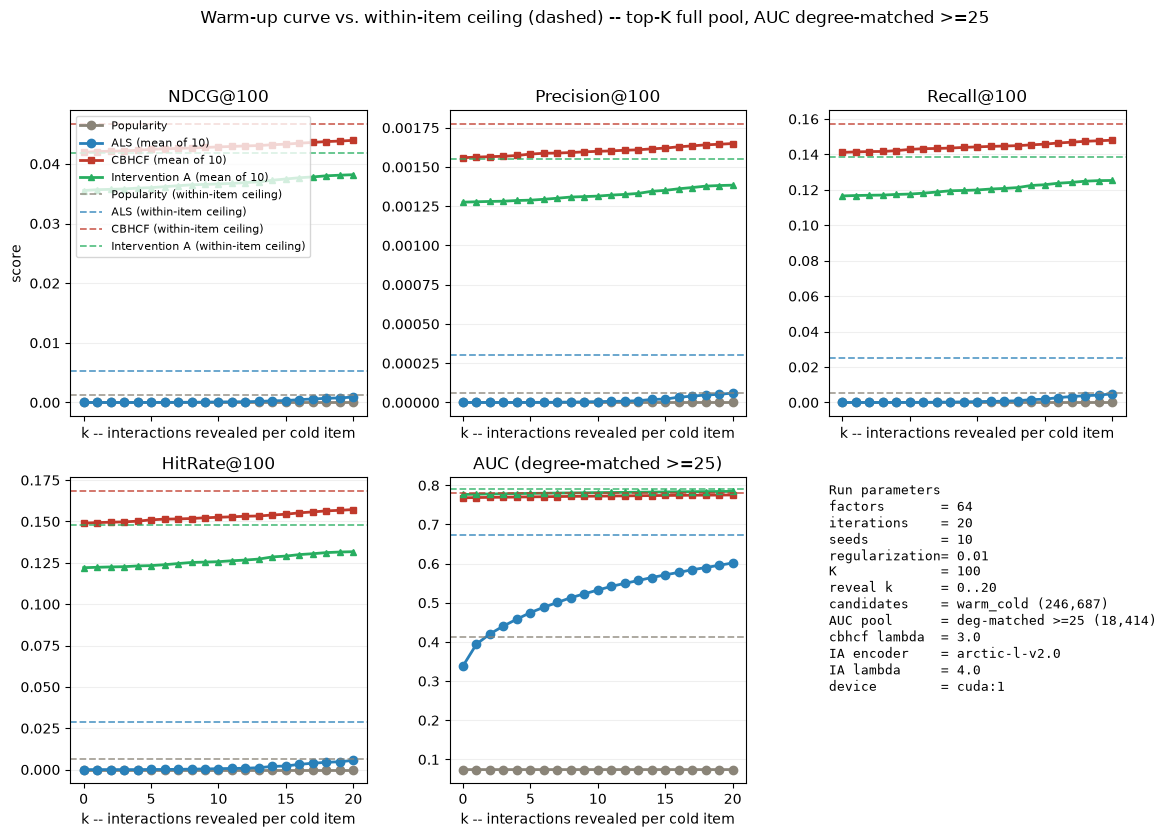

In [13]:
%%time
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS)):
    als_mean = np.array(als_curve[metric]["mean"])
    als_std = np.array(als_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    if RUN_POP:
        ax.plot(K_LEVELS, pop_curve[metric]["mean"], marker="o", markersize=6, linewidth=2,
                color="#8A8478", label=show_label("Popularity"))
    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    if RUN_CBHCF:
        cb_mean = np.array(cbhcf_curve[metric]["mean"]); cb_std = np.array(cbhcf_curve[metric]["std"])
        ax.plot(K_LEVELS, cb_mean, marker="s", markersize=5, linewidth=2,
                color="#c0392b", label=show_label(f"CBHCF (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, cb_mean - cb_std, cb_mean + cb_std, color="#c0392b", alpha=0.15, linewidth=0)
    if RUN_IA:
        ia_mean = np.array(ia_curve[metric]["mean"]); ia_std = np.array(ia_curve[metric]["std"])
        ax.plot(K_LEVELS, ia_mean, marker="^", markersize=5, linewidth=2,
                color="#27ae60", label=show_label(f"Intervention A (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, ia_mean - ia_std, ia_mean + ia_std, color="#27ae60", alpha=0.15, linewidth=0)
    if RUN_POP:
        ax.axhline(pop_ref["mean"][metric], color="#8A8478", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("Popularity (within-item ceiling)"))
    ax.axhline(als_ref["mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (within-item ceiling)"))
    if RUN_CBHCF:
        ax.axhline(cbhcf_ref["mean"][metric], color="#c0392b", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("CBHCF (within-item ceiling)"))
    if RUN_IA:
        ax.axhline(ia_ref["mean"][metric], color="#27ae60", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("Intervention A (within-item ceiling)"))

    ax.set_title("AUC (degree-matched >=25)" if metric == "AUC" else f"{metric}@{K}")
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")

# Run-parameters panel in the empty 6th subplot (5 metrics -> axes[5] is free).
_params = [("factors", ALS_PARAMS["factors"]), ("iterations", ALS_PARAMS["iterations"]),
           ("seeds", N_SEEDS), ("regularization", ALS_PARAMS["regularization"]), ("K", K),
           ("reveal k", f"{K_LEVELS[0]}..{K_LEVELS[-1]}"),
           ("candidates", f"warm_cold ({len(seed_models[0]._candidate_ids):,})"),
           ("AUC pool", f"deg-matched >=25 ({len(seed_models[0]._auc_candidate_ids):,})"),
           ("cbhcf lambda", CBHCF_LAMBDA if RUN_CBHCF else "off"),
           ("IA encoder", IA_CFG["model_key"] if RUN_IA else "off"),
           ("IA lambda", IA_CFG["content_weight"] if RUN_IA else "off"),
           ("device", DEVICE)]
axes[5].axis("off")
axes[5].text(0.0, 0.98, "Run parameters\n" + "\n".join(f"{k:<14}= {v}" for k, v in _params),
             family="monospace", fontsize=9, va="top", transform=axes[5].transAxes)

fig.suptitle("Warm-up curve vs. within-item ceiling (dashed) -- top-K full pool, AUC degree-matched >=25", y=1.04)
plt.tight_layout()
plt.savefig("warmup_curve_mode_a.png", dpi=120, bbox_inches="tight")
print("Saved Mode A warm-up curve to warmup_curve_mode_a.png")

## 9b. Head / torso / tail breakdown (secondary)

Splits the cold items into equal-count degree terciles (by TOTAL interactions) and reports, at the
within-item ceiling per bucket: the **degree range** each bucket spans, **HitRate@K** (fraction of
that bucket's held-out interactions retrieved into top-K) and **NDCG@K** (its rank-discounted
version — are head items not just *hit* more often but ranked *higher*?). The mainstream,
low-friction way to surface popularity / long-tail effects (Steck 2011 popularity-stratified
evaluation; the head/torso/tail breakdown standard in long-tail recsys), complementary to the
degree-matched AUC. Reading it: even fully warm, do low-degree (tail) cold items retrieve worse
than head? Buckets are equal-count in items, so each holds ~n_cold/3 items and ~5x that many
held-out interactions (the fixed last-5 test). The **Popularity floor** is shown per bucket
alongside ALS, so you can see whether ALS's edge over popularity is uniform across degree or (as
expected) concentrated in the head, where raw counts are high.

free VRAM: 12.2 GB   chunks: ALS 1,536, CBHCF 1,024, IA 1,024
Head/torso/tail at the within-item ceiling (equal-count degree terciles, K=100):
  bucket    degree range  median  items  ALS HitR  ALS NDCG   CB HitR   CB NDCG   IA HitR   IA NDCG  Pop HitR  Pop NDCG
  tail             25-32      27    909    0.0101    0.0020    0.1706    0.0521    0.1498    0.0463    0.0000    0.0000
  torso            32-49      38    909    0.0092    0.0017    0.1590    0.0452    0.1338    0.0397    0.0000    0.0000
  head           49-1759      75    909    0.0625    0.0128    0.1532    0.0405    0.1397    0.0370    0.0172    0.0035
Saved head/torso/tail breakdown to warmup_tail_breakdown.png
CPU times: user 10.5 s, sys: 9.99 s, total: 20.5 s
Wall time: 20.5 s


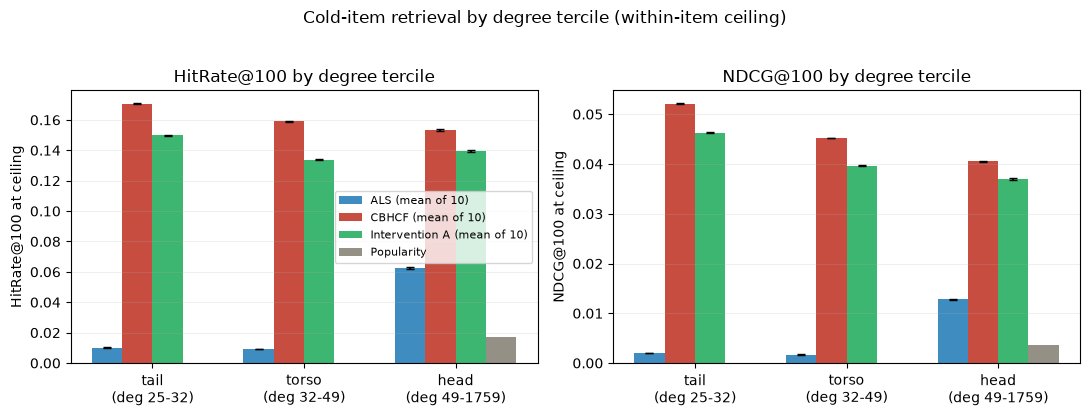

In [14]:
%%time
# ALS's chunk was auto-computed by prepare_gpu_recommend(vram_budget_gb=8.0) when the card was
# empty -- it still asks for an ~8 GB score block and OOMs. Re-budget for a card carrying ONE arm's
# ~8.3 GB content block. (With `activate()` swapping arms in and out, only one is ever resident, so
# this budget is the same whether or not Intervention A is running -- which is the point.)
import torch
torch.cuda.empty_cache()
print(f"free VRAM: {torch.cuda.mem_get_info(torch.device(DEVICE))[0] / 1e9:.1f} GB   "
      f"chunks: ALS {seed_models[0]._gpu_chunk:,}"
      + (f", CBHCF {cbhcf_models[0]._gpu_chunk:,}" if RUN_CBHCF else "")
      + (f", IA {ia_models[0]._gpu_chunk:,}" if RUN_IA else ""))

item_bucket, bucket_labels, bucket_info = ev.cold_item_degree_buckets(dataset, n_buckets=3)
strata = ev.ceiling_metrics_by_bucket(seed_models, dataset, item_bucket, K=K, n_buckets=3)
torch.cuda.empty_cache()
# Popularity floor per bucket -- PopularityModel has fold_in_ceiling/recommend, so the same call
# works. Reveals whether ALS's edge over popularity is uniform across degree or head-concentrated.
pop_strata = ev.ceiling_metrics_by_bucket([pop_model], dataset, item_bucket, K=K, n_buckets=3) if RUN_POP else None
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_strata = ev.ceiling_metrics_by_bucket(cbhcf_models, dataset, item_bucket, K=K, n_buckets=3) if RUN_CBHCF else None
torch.cuda.empty_cache()
if RUN_IA:
    activate(ia_models)
ia_strata = ev.ceiling_metrics_by_bucket(ia_models, dataset, item_bucket, K=K, n_buckets=3) if RUN_IA else None
torch.cuda.empty_cache()

print(f"Head/torso/tail at the within-item ceiling (equal-count degree terciles, K={K}):")
hdr = f"  {'bucket':<7}{'degree range':>15}{'median':>8}{'items':>7}{'ALS HitR':>10}{'ALS NDCG':>10}"
if RUN_CBHCF:
    hdr += f"{'CB HitR':>10}{'CB NDCG':>10}"
if RUN_IA:
    hdr += f"{'IA HitR':>10}{'IA NDCG':>10}"
if RUN_POP:
    hdr += f"{'Pop HitR':>10}{'Pop NDCG':>10}"
print(hdr)
for b, lab in enumerate(bucket_labels):
    bi, s = bucket_info[b], strata[b]
    rng = f"{bi['deg_min']}-{bi['deg_max']}"
    row = f"  {lab:<7}{rng:>15}{bi['deg_median']:>8}{bi['n_items']:>7,}{s['hitrate']:>10.4f}{s['ndcg']:>10.4f}"
    if RUN_CBHCF:
        cs = cbhcf_strata[b]
        row += f"{cs['hitrate']:>10.4f}{cs['ndcg']:>10.4f}"
    if RUN_IA:
        ias = ia_strata[b]
        row += f"{ias['hitrate']:>10.4f}{ias['ndcg']:>10.4f}"
    if RUN_POP:
        ps = pop_strata[b]
        row += f"{ps['hitrate']:>10.4f}{ps['ndcg']:>10.4f}"
    print(row)

# Two panels (HitRate, NDCG); ALS vs Popularity per degree tercile.
fig, (axh, axn) = plt.subplots(1, 2, figsize=(11, 4))
xs = np.arange(len(bucket_labels)); w = 0.38
xtl = [f"{bucket_labels[b]}\n(deg {bucket_info[b]['deg_min']}-{bucket_info[b]['deg_max']})"
       for b in range(len(bucket_labels))]
_nbars = 1 + int(RUN_POP) + int(RUN_CBHCF) + int(RUN_IA)
w = 0.8 / _nbars
for ax, metric, mlabel in [(axh, "hitrate", f"HitRate@{K}"), (axn, "ndcg", f"NDCG@{K}")]:
    _slot = 0
    ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [strata[b][metric] for b in range(len(bucket_labels))], w,
           yerr=[strata[b][metric + "_std"] for b in range(len(bucket_labels))], capsize=3,
           color="#2980b9", alpha=0.9, label=f"ALS (mean of {N_SEEDS})")
    if RUN_CBHCF:
        _slot += 1
        ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [cbhcf_strata[b][metric] for b in range(len(bucket_labels))], w,
               yerr=[cbhcf_strata[b][metric + "_std"] for b in range(len(bucket_labels))], capsize=3,
               color="#c0392b", alpha=0.9, label=f"CBHCF (mean of {N_SEEDS})")
    if RUN_IA:
        _slot += 1
        ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [ia_strata[b][metric] for b in range(len(bucket_labels))], w,
               yerr=[ia_strata[b][metric + "_std"] for b in range(len(bucket_labels))], capsize=3,
               color="#27ae60", alpha=0.9, label=f"Intervention A (mean of {N_SEEDS})")
    if RUN_POP:
        _slot += 1
        ax.bar(xs + (_slot - (_nbars - 1) / 2) * w, [pop_strata[b][metric] for b in range(len(bucket_labels))], w,
               color="#8A8478", alpha=0.9, label="Popularity")
    ax.set_xticks(xs); ax.set_xticklabels(xtl)
    ax.set_ylabel(f"{mlabel} at ceiling"); ax.set_title(f"{mlabel} by degree tercile")
    ax.grid(axis="y", alpha=0.2)
axh.legend(fontsize=8)
fig.suptitle("Cold-item retrieval by degree tercile (within-item ceiling)", y=1.03)
plt.tight_layout()
plt.savefig("warmup_tail_breakdown.png", dpi=120, bbox_inches="tight")
print("Saved head/torso/tail breakdown to warmup_tail_breakdown.png")

# Log the head/torso/tail ceiling breakdown to the (still-open) ALS run as summary values.
for b, lab in enumerate(bucket_labels):
    als_run.summary[f"tail/{lab}/HitRate"] = strata[b]["hitrate"]
    als_run.summary[f"tail/{lab}/NDCG"] = strata[b]["ndcg"]
    if RUN_CBHCF:
        cbhcf_run.summary[f"tail/{lab}/HitRate"] = cbhcf_strata[b]["hitrate"]
        cbhcf_run.summary[f"tail/{lab}/NDCG"] = cbhcf_strata[b]["ndcg"]
    if RUN_IA:
        ia_run.summary[f"tail/{lab}/HitRate"] = ia_strata[b]["hitrate"]
        ia_run.summary[f"tail/{lab}/NDCG"] = ia_strata[b]["ndcg"]

## 10. Warm-up curve — item-to-user view (Mode B)

Section 9 asks, from a *user's* perspective: does this cold item surface in my personal
top-K? This asks the same question from the opposite direction — for a single cold item, rank
every user by predicted affinity, and check whether the users known (from the reserved test
set) to actually be interested in it land near the top of *its* top-K. Same fold-in factors as
Section 7/9, just a transposed ranking axis — see `eval.sweep_item_to_user_gpu`.

**Why Popularity has no line here, and Activity does.** Popularity assigns every user an
identical score for a given item — no per-user signal to rank users *by*. But the *principle*
behind it — rank by observed volume, no personalization — has a direct dual on this axis:
**global user activity** (`pop.ActivityModel`), ranking users by their total interaction count
in `ref_train`, frozen exactly like `user_factors` are treated everywhere else.

**Why `K=10` here, not Section 9's `K=100`.** Mode B's candidate pool is the user population
(millions), not the warm-item catalog — each cold item is ranked over users. A small K keeps the
metric discriminating rather than saturating. (The exact K was tuned on the earlier small-scale
proof-of-concept; revisit it for Amazon Books when Mode B is run on GPU.)

**Downsampled Test Set — now an identity.** Recall@K is capped at `K/r_i` and Precision@K at
`r_i/K` for an item with `r_i` reserved test users. Under the OLD split (test = everything after
reveal 20), `r_i` varied widely, so `eval.build_mode_b_context` drew a fixed 5-user sample per item
for comparability. The leave-last-5-out split makes `r_i` **exactly 5 for every cold item**, so the
downsample-to-5 is now a no-op (it selects all 5) — the comparability fix is baked into the split.
AUC stays on the full (now 5-user) reserved test set, over the full user population (not
degree-matched — Mode B's floor is the Activity model, which stays as the user-degree baseline).

**`eval.mode_b_ceiling`** reports what a hypothetically perfect ranking would score on each
metric — NDCG/HitRate/AUC are trivially 1.0; Precision@K and Recall@K actually depend on `r_i`
and are the two worth reading against their ceiling.

In [15]:
%%time
DOWNSAMPLE_SIZE = 5
K_MODE_B = 10
METRICS_MODE_B = ev.METRICS_MODE_B  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]

mode_b_ctx = ev.build_mode_b_context(dataset, downsample_size=DOWNSAMPLE_SIZE, seed=42)
activity_model = pop.ActivityModel().fit(dataset.ref_train)

print(f"Downsampled test set: {mode_b_ctx.downsampled_test_matrix.nnz:,} interactions across "
      f"{len(dataset.cold_item_ids)} items ({DOWNSAMPLE_SIZE} per item, exactly).")

ceiling = ev.mode_b_ceiling(dataset, mode_b_ctx, K=K_MODE_B)
print(f"Mode B ceiling at K={K_MODE_B} (perfect ranking, fixed across all k): "
      + "   ".join(f"{m}={ceiling[m]:.4f}" for m in METRICS_MODE_B))

# GPU Mode B: scores only the cold-item columns (no dense score matrix), so it runs at Amazon scale
# (a dense-score-matrix Mode B would not fit here). AUC is the full-user-population average-rank AUC
# (gpu_retrieval.mode_b_auc) -- the non-saturating companion to the four Downsampled Test Set metrics.
als_b_curve, n_eval_b_per_k = ev.sweep_item_to_user_gpu(seed_models, dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)
if RUN_CBHCF:
    activate(cbhcf_models)
cbhcf_b_curve = ev.sweep_item_to_user_gpu(cbhcf_models, dataset, mode_b_ctx, K_LEVELS,
                                          K=K_MODE_B)[0] if RUN_CBHCF else None
if RUN_IA:
    activate(ia_models)
ia_b_curve = ev.sweep_item_to_user_gpu(ia_models, dataset, mode_b_ctx, K_LEVELS,
                                       K=K_MODE_B)[0] if RUN_IA else None

# Within-item ceiling (Mode B analog of Section 6): each cold item folded in with ALL its pre-test
# interactions, ranking users, on the same last-5 test -- the dashed line the ALS curve warms up
# toward. (Activity is k-invariant, so its "ceiling" is just its flat curve -- no separate line.)
mode_b_ref = ev.mode_b_reference(seed_models, dataset, mode_b_ctx, K=K_MODE_B)
cbhcf_b_ref = (activate(cbhcf_models) or ev.mode_b_reference(cbhcf_models, dataset, mode_b_ctx, K=K_MODE_B)) if RUN_CBHCF else None
ia_b_ref = (activate(ia_models) or ev.mode_b_reference(ia_models, dataset, mode_b_ctx, K=K_MODE_B)) if RUN_IA else None
print("Mode B within-item ceiling (ALS, all pre-test history folded in): "
      + "   ".join(f"{m}={mode_b_ref['mean'][m]:.4f}" for m in METRICS_MODE_B))

# Activity floor: deterministic, so cache it. Its AUC (over all users, same basis as ALS Mode B AUC)
# comes from ev.activity_auc_curve -- the sweep leaves Activity's AUC NaN (it ranks by activity, not
# factors), so we fill it here. Keyed by K_MODE_B, K_LEVELS, and the downsample size.
def _activity_b_curve():
    c = ev.sweep_item_to_user_gpu([activity_model], dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)[0]
    c["AUC"] = ev.activity_auc_curve(activity_model, dataset, K_LEVELS, device=DEVICE)
    return c
activity_b_curve = cache_pickle("activity_b_curve", _activity_b_curve,
                                params=(FP, K_MODE_B, tuple(K_LEVELS), DOWNSAMPLE_SIZE))

# --- Weights & Biases: open the Activity run; als_run (from Section 9) also logs its Mode B metrics ---
activity_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"activity-{RUN_TAG}",
                          mode=WANDB_MODE, reinit="create_new")
als_run.define_metric("mode_b/*", step_metric="k")
activity_run.define_metric("mode_b/*", step_metric="k")

print("\nItem-to-user (Mode B) sweep:")
for i, k in enumerate(K_LEVELS):
    print(f"k={k:>2}  eval items={n_eval_b_per_k[i]:>4}  "
          + "  ".join(f"{m}: ALS={als_b_curve[m]['mean'][i]:.4f} "
                       + (f"CBHCF={cbhcf_b_curve[m]['mean'][i]:.4f} " if RUN_CBHCF else "")
                       + (f"IA={ia_b_curve[m]['mean'][i]:.4f} " if RUN_IA else "")
                       + f"Activity={activity_b_curve[m]['mean'][i]:.4f}" for m in METRICS_MODE_B))

    # Log this reveal level to W&B (mode_b/* against step metric k)
    als_run.log({"k": k, **{f"mode_b/{m}": als_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})
    activity_run.log({"k": k, **{f"mode_b/{m}": activity_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})
    if RUN_CBHCF:
        cbhcf_run.log({"k": k, **{f"mode_b/{m}": cbhcf_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})
    if RUN_IA:
        ia_run.log({"k": k, **{f"mode_b/{m}": ia_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})

# Finish both runs -- als_run has now logged Mode A + Mode B.
als_run.finish()
activity_run.finish()
if RUN_CBHCF:
    cbhcf_run.finish()
if RUN_IA:
    ia_run.finish()

Downsampled test set: 13,635 interactions across 2727 items (5 per item, exactly).
Mode B ceiling at K=10 (perfect ranking, fixed across all k): NDCG=1.0000   Precision=0.5000   Recall=1.0000   HitRate=1.0000   AUC=1.0000
[sweep_item_to_user_gpu] setup=0.1s  foldin=3.7s  score=7.9s  metric=3.6s  auc=51.9s  total=67.2s
[sweep_item_to_user_gpu] setup=0.1s  foldin=3.9s  score=16.3s  metric=3.7s  auc=59.4s  total=83.4s
[sweep_item_to_user_gpu] setup=0.1s  foldin=4.0s  score=16.3s  metric=3.7s  auc=59.4s  total=83.5s
Mode B within-item ceiling (ALS, all pre-test history folded in): NDCG=0.0049   Precision=0.0027   Recall=0.0055   HitRate=0.0247   AUC=0.7428



Item-to-user (Mode B) sweep:
k= 0  eval items=2727  NDCG: ALS=0.0001 CBHCF=0.0132 IA=0.0127 Activity=0.0006  Precision: ALS=0.0000 CBHCF=0.0077 IA=0.0073 Activity=0.0004  Recall: ALS=0.0001 CBHCF=0.0155 IA=0.0147 Activity=0.0007  HitRate: ALS=0.0004 CBHCF=0.0715 IA=0.0682 Activity=0.0037  AUC: ALS=0.5000 CBHCF=0.7999 IA=0.8009 Activity=0.6724
k= 1  eval items=2727  NDCG: ALS=0.0023 CBHCF=0.0132 IA=0.0126 Activity=0.0006  Precision: ALS=0.0014 CBHCF=0.0078 IA=0.0073 Activity=0.0004  Recall: ALS=0.0028 CBHCF=0.0156 IA=0.0146 Activity=0.0007  HitRate: ALS=0.0131 CBHCF=0.0722 IA=0.0680 Activity=0.0037  AUC: ALS=0.6607 CBHCF=0.8004 IA=0.8016 Activity=0.6724
k= 2  eval items=2727  NDCG: ALS=0.0029 CBHCF=0.0134 IA=0.0130 Activity=0.0006  Precision: ALS=0.0016 CBHCF=0.0079 IA=0.0075 Activity=0.0004  Recall: ALS=0.0033 CBHCF=0.0158 IA=0.0150 Activity=0.0007  HitRate: ALS=0.0153 CBHCF=0.0734 IA=0.0699 Activity=0.0037  AUC: ALS=0.6703 CBHCF=0.8006 IA=0.8019 Activity=0.6724
k= 3  eval items=2727 

k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█
mode_a/AUC,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇████
mode_a/HitRate,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇▇█
mode_a/NDCG,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▃▅▆▆▇█
mode_a/Precision,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇▇█
mode_a/Recall,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇▇█
mode_b/AUC,▁▆▆▇▇▇▇▇▇▇▇██████████
mode_b/HitRate,▁▆▆▇▇▇▇▇▇▇▇▇█████████
mode_b/NDCG,▁▅▆▆▆▆▆▆▆▆▇▇▇▇███████
mode_b/Precision,▁▅▆▆▇▆▇▇▇▇▇▇▇████████
+1,...


k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
mode_b/AUC,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▆▇▇▇██
mode_b/HitRate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_b/NDCG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█████
mode_b/Precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_b/Recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
k,20
mode_b/AUC,0.67243
mode_b/HitRate,0.00367
mode_b/NDCG,0.00065
mode_b/Precision,0.00037


k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█
mode_a/AUC,▁▂▂▂▃▃▄▄▅▅▅▆▆▆▆▇▇▇███
mode_a/HitRate,▁▁▁▂▂▃▃▃▃▄▄▄▅▅▅▆▆▇▇██
mode_a/NDCG,▁▁▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▇▇██
mode_a/Precision,▁▁▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▇▇██
mode_a/Recall,▁▁▁▂▂▃▃▃▃▄▄▄▅▅▅▆▆▇▇██
mode_b/AUC,▁▂▂▂▃▃▄▄▅▅▅▅▆▆▆▇▇▇███
mode_b/HitRate,▁▂▃▂▃▃▅▅▅▅▅▅▅▅▅▆▆▆▇▇█
mode_b/NDCG,▁▁▂▁▂▃▃▃▄▄▄▄▄▅▅▆▆▇▇██
mode_b/Precision,▁▁▂▂▂▃▄▄▄▄▄▄▄▄▅▆▆▆▇▇█
+1,...


k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█
mode_a/AUC,▁▂▂▃▃▃▄▄▅▅▅▆▆▆▆▇▇▇███
mode_a/HitRate,▁▁▁▁▂▂▂▃▃▃▄▄▄▅▆▆▇▇███
mode_a/NDCG,▁▁▂▂▂▂▃▃▄▄▄▄▅▅▆▆▇▇███
mode_a/Precision,▁▁▁▁▂▂▂▃▃▃▄▄▄▅▅▆▇▇███
mode_a/Recall,▁▁▁▁▂▂▂▃▃▃▄▄▄▅▆▆▇▇███
mode_b/AUC,▁▂▂▃▃▄▄▄▅▅▅▆▆▆▇▇▇▇███
mode_b/HitRate,▁▁▄▅▆▄▅▅▇▅▅▆▆▅▅▄▆▆▇██
mode_b/NDCG,▁▁▃▃▅▅▅▆▆▅▄▅▄▅▄▅▆▆▇██
mode_b/Precision,▁▁▂▃▅▄▅▅▆▅▅▅▅▅▅▅▆▇▇██
+1,...


CPU times: user 3min 50s, sys: 35.1 s, total: 4min 25s
Wall time: 4min 30s


Saved Mode B warm-up curve to warmup_curve_mode_b.png
CPU times: user 706 ms, sys: 235 ms, total: 941 ms
Wall time: 2.4 s


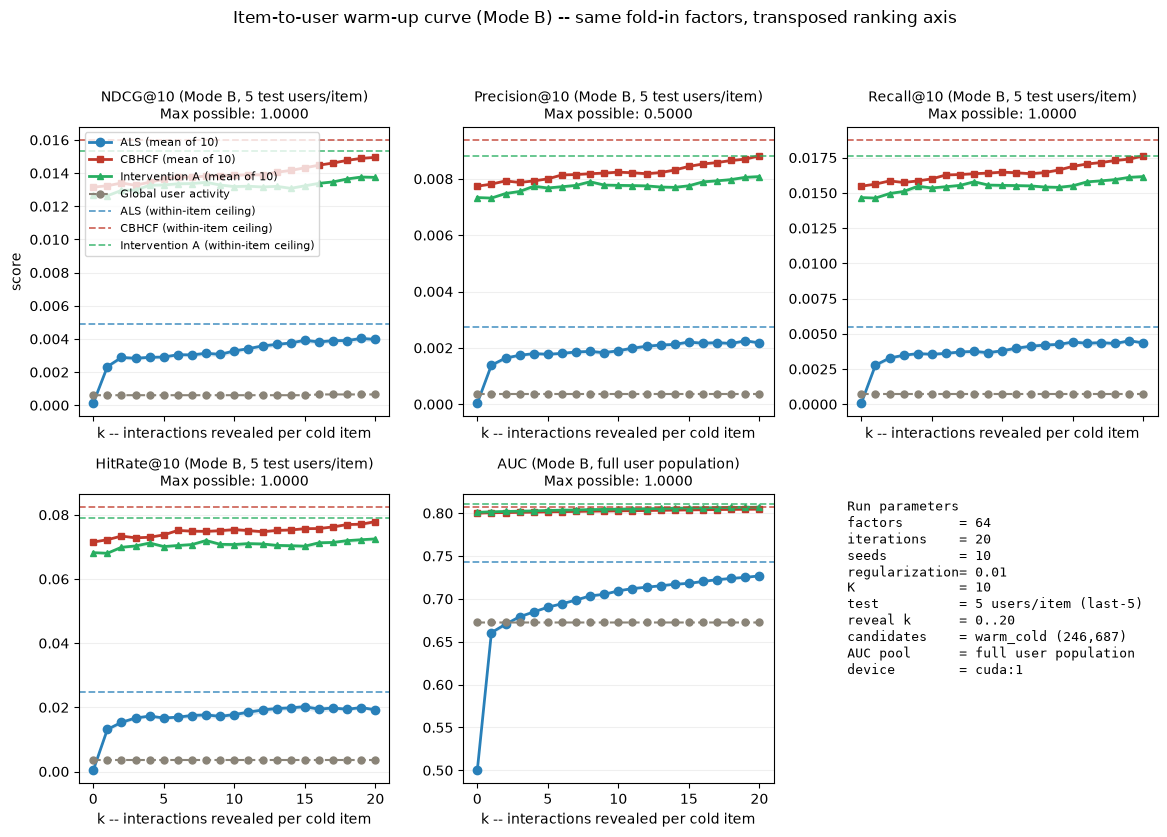

In [16]:
%%time
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS_MODE_B)):
    als_mean = np.array(als_b_curve[metric]["mean"])
    als_std = np.array(als_b_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    if RUN_CBHCF:
        cb_mean = np.array(cbhcf_b_curve[metric]["mean"]); cb_std = np.array(cbhcf_b_curve[metric]["std"])
        ax.plot(K_LEVELS, cb_mean, marker="s", markersize=5, linewidth=2,
                color="#c0392b", label=show_label(f"CBHCF (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, cb_mean - cb_std, cb_mean + cb_std, color="#c0392b", alpha=0.15, linewidth=0)
    if RUN_IA:
        ia_mean = np.array(ia_b_curve[metric]["mean"]); ia_std = np.array(ia_b_curve[metric]["std"])
        ax.plot(K_LEVELS, ia_mean, marker="^", markersize=5, linewidth=2,
                color="#27ae60", label=show_label(f"Intervention A (mean of {N_SEEDS})"))
        ax.fill_between(K_LEVELS, ia_mean - ia_std, ia_mean + ia_std, color="#27ae60", alpha=0.15, linewidth=0)
    ax.plot(K_LEVELS, activity_b_curve[metric]["mean"], marker="o", markersize=5, linewidth=1.5,
            linestyle="--", color="#8A8478", label=show_label("Global user activity"))
    ax.axhline(mode_b_ref["mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (within-item ceiling)"))
    if RUN_CBHCF:
        ax.axhline(cbhcf_b_ref["mean"][metric], color="#c0392b", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("CBHCF (within-item ceiling)"))
    if RUN_IA:
        ax.axhline(ia_b_ref["mean"][metric], color="#27ae60", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("Intervention A (within-item ceiling)"))

    title_line1 = ("AUC (Mode B, full user population)" if metric == "AUC"
                   else f"{metric}@{K_MODE_B} (Mode B, {DOWNSAMPLE_SIZE} test users/item)")
    ax.set_title(f"{title_line1}\nMax possible: {ceiling[metric]:.4f}", fontsize=10)
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")

# Run-parameters panel in the empty 6th subplot (5 metrics -> axes[5] is free).
_params = [("factors", ALS_PARAMS["factors"]), ("iterations", ALS_PARAMS["iterations"]),
           ("seeds", N_SEEDS), ("regularization", ALS_PARAMS["regularization"]), ("K", K_MODE_B),
           ("test", f"{DOWNSAMPLE_SIZE} users/item (last-5)"),
           ("reveal k", f"{K_LEVELS[0]}..{K_LEVELS[-1]}"),
           ("candidates", f"warm_cold ({len(seed_models[0]._candidate_ids):,})"),
           ("AUC pool", "full user population"),
           ("device", DEVICE)]
axes[5].axis("off")
axes[5].text(0.0, 0.98, "Run parameters\n" + "\n".join(f"{k:<14}= {v}" for k, v in _params),
             family="monospace", fontsize=9, va="top", transform=axes[5].transAxes)

fig.suptitle("Item-to-user warm-up curve (Mode B) -- same fold-in factors, transposed ranking axis", y=1.04)
plt.tight_layout()
plt.savefig("warmup_curve_mode_b.png", dpi=120, bbox_inches="tight")
print("Saved Mode B warm-up curve to warmup_curve_mode_b.png")

## 11. Persist results

The warm-up curves and warm-item reference are the deliverable of this run, but they otherwise live
only in cell outputs / kernel memory -- clearing outputs or restarting the kernel loses them (only
the PNGs and the Popularity caches survive). This dumps everything -- config + every curve +
reference + n_eval + Mode B ceiling -- to a timestamped pickle (exact, for re-plotting) and JSON
(human-readable) under `../outputs/`, so the final run is fully recoverable. To copy the results off
WSL afterwards: `cp ~/699-gpu-bench/outputs/* /mnt/c/699-gpu-bench-outputs/`.

In [17]:
%%time
import json, pickle, datetime

results = {
    "config": {
        "ALS_PARAMS": ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K, "K_LEVELS": K_LEVELS,
        "K_MODE_B": K_MODE_B, "DOWNSAMPLE_SIZE": DOWNSAMPLE_SIZE, "DEVICE": DEVICE, "RUN_POP": RUN_POP,
        "n_users": int(dataset.n_users), "n_items": int(dataset.n_items),
        "n_cold_items": int(len(dataset.cold_item_ids)),
        "test_per_cold_item": int(dataset.test_matrix.nnz / max(len(dataset.cold_item_ids), 1)),
        "auc_min_degree": 25,   # degree-matched AUC pool threshold (reserve degree-matching for AUC)
        "RUN_CBHCF": RUN_CBHCF, "CBHCF_LAMBDA": CBHCF_LAMBDA,
        "CBHCF_FIELD_WEIGHTS": CBHCF_FIELD_WEIGHTS,
        "CBHCF_LAMBDA_PROVENANCE": CBHCF_LAMBDA_PROVENANCE,
        "RUN_IA": RUN_IA, "IA_CONFIG": IA_CFG,
        "dataset_fingerprint": list(FP),
        "n_cold_val_items": int(len(dataset.cold_val.cold_item_ids)) if dataset.cold_val else 0,
        "ref_train_nnz": int(dataset.ref_train.nnz), "ref_test_nnz": int(dataset.ref_test.nnz),
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    },
    # "reference" is now the WITHIN-ITEM ceiling (cold items folded in with all pre-test history on the
    # last-5 test), not the old cross-population warm-item reference.
    "reference": {"als": als_ref, "pop": pop_ref, "cbhcf": cbhcf_ref, "intervention_a": ia_ref},
    "mode_a": {"als_curve": als_curve, "pop_curve": pop_curve, "cbhcf_curve": cbhcf_curve,
               "intervention_a_curve": ia_curve,
               "n_eval_per_k": n_eval_per_k,
               "strata": strata, "pop_strata": pop_strata, "cbhcf_strata": cbhcf_strata,
               "intervention_a_strata": ia_strata,
               "bucket_labels": bucket_labels, "bucket_info": bucket_info},
    "mode_b": {"als_curve": als_b_curve, "activity_curve": activity_b_curve,
               "cbhcf_curve": cbhcf_b_curve, "cbhcf_within_item_ceiling": cbhcf_b_ref,
               "intervention_a_curve": ia_b_curve, "intervention_a_within_item_ceiling": ia_b_ref,
               "n_eval_per_k": n_eval_b_per_k, "ceiling": ceiling, "within_item_ceiling": mode_b_ref},
}

os.makedirs("../outputs", exist_ok=True)
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base = f"../outputs/baseline_cf_{stamp}"
with open(base + ".pkl", "wb") as f:
    pickle.dump(results, f)
with open(base + ".json", "w") as f:
    json.dump(results, f, indent=2, default=lambda o: float(o) if hasattr(o, "__float__") else str(o))
print(f"Saved results to {base}.pkl and {base}.json")
print(f"  seeds={N_SEEDS}  iters={ALS_PARAMS['iterations']}  factors={ALS_PARAMS['factors']}  "
      f"K={K}  K_LEVELS={K_LEVELS[0]}..{K_LEVELS[-1]}  device={DEVICE}")

# ---- Consolidated results recap (headline top-K first; AUC is degree-matched, reported last) ----
print("\n" + "=" * 78)
print("RESULTS RECAP  (top-K on the full warm_cold pool; AUC on the degree-matched >=25 pool)")
print("=" * 78)
lastk = len(K_LEVELS) - 1
print(f"\nMode A -- user-centric (K={K}):")
print(f"  {'metric':<12}{'Pop k=0':>10}{'ALS k=0':>10}{'CB k=0':>10}{'IA k=0':>10}"
      f"{'Pop k=20':>11}{'ALS k=20':>11}{'CB k=20':>11}{'IA k=20':>11}"
      f"{'Pop ceil':>11}{'ALS ceil':>11}{'CB ceil':>11}{'IA ceil':>11}")
_nan = float("nan")
for m in METRICS:
    row = (f"  {m:<12}"
           f"{(pop_curve[m]['mean'][0] if RUN_POP else _nan):>10.4f}"
           f"{als_curve[m]['mean'][0]:>10.4f}"
           f"{(cbhcf_curve[m]['mean'][0] if RUN_CBHCF else _nan):>10.4f}"
           f"{(ia_curve[m]['mean'][0] if RUN_IA else _nan):>10.4f}"
           f"{(pop_curve[m]['mean'][lastk] if RUN_POP else _nan):>11.4f}"
           f"{als_curve[m]['mean'][lastk]:>11.4f}"
           f"{(cbhcf_curve[m]['mean'][lastk] if RUN_CBHCF else _nan):>11.4f}"
           f"{(ia_curve[m]['mean'][lastk] if RUN_IA else _nan):>11.4f}"
           f"{(pop_ref['mean'][m] if RUN_POP else _nan):>11.4f}"
           f"{als_ref['mean'][m]:>11.4f}"
           f"{(cbhcf_ref['mean'][m] if RUN_CBHCF else _nan):>11.4f}"
           f"{(ia_ref['mean'][m] if RUN_IA else _nan):>11.4f}")
    print(row)

print(f"\nMode A tail breakdown -- within-item ceiling by degree tercile (K={K}):")
for b in range(len(bucket_labels)):
    bi, s = bucket_info[b], strata[b]
    print(f"  {bucket_labels[b]:<6} deg {bi['deg_min']}-{bi['deg_max']} (med {bi['deg_median']}, "
          f"{bi['n_items']:,} items):  HitRate={s['hitrate']:.4f}  NDCG={s['ndcg']:.4f}")

print(f"\nMode B -- item-to-user (K={K_MODE_B}; AUC full user population):")
print(f"  {'metric':<12}{'Act k=20':>11}{'ALS k=20':>11}{'CB k=20':>11}{'IA k=20':>11}"
      f"{'ALS ceil':>11}{'CB ceil':>11}{'IA ceil':>11}{'max':>9}")
for m in METRICS_MODE_B:
    print(f"  {m:<12}{activity_b_curve[m]['mean'][lastk]:>11.4f}{als_b_curve[m]['mean'][lastk]:>11.4f}"
          f"{(cbhcf_b_curve[m]['mean'][lastk] if RUN_CBHCF else _nan):>11.4f}"
          f"{(ia_b_curve[m]['mean'][lastk] if RUN_IA else _nan):>11.4f}"
          f"{mode_b_ref['mean'][m]:>11.4f}"
          f"{(cbhcf_b_ref['mean'][m] if RUN_CBHCF else _nan):>11.4f}"
          f"{(ia_b_ref['mean'][m] if RUN_IA else _nan):>11.4f}{ceiling[m]:>9.4f}")
print("=" * 78)

# The comparison this notebook exists to make. Both hybrids wrap the SAME ten ALS fits and differ
# only in how an item's own text is represented, so this difference is attributable to that and
# nothing else. cold_val predicted TF-IDF ahead by ~20% on NDCG while every encoder led on AUC --
# these are the reported (cold TEST, 10-seed) numbers for the same question.
if RUN_CBHCF and RUN_IA:
    print("\nCBHCF (TF-IDF prose) vs Intervention A (arctic embeddings), same ALS seeds:")
    print(f"  {'metric':<12}{'CBHCF k=0':>12}{'IA k=0':>12}{'delta':>9}"
          f"{'CBHCF ceil':>13}{'IA ceil':>11}{'delta':>9}")
    for m in METRICS:
        c0, i0 = cbhcf_curve[m]["mean"][0], ia_curve[m]["mean"][0]
        cc, ic = cbhcf_ref["mean"][m], ia_ref["mean"][m]
        d0 = (i0 / c0 - 1) * 100 if c0 else _nan
        dc = (ic / cc - 1) * 100 if cc else _nan
        print(f"  {m:<12}{c0:>12.4f}{i0:>12.4f}{d0:>8.1f}%{cc:>13.4f}{ic:>11.4f}{dc:>8.1f}%")
    print(f"  (cold_val predicted: CBHCF {STEEL_CFG['cbhcf']['coldval_objective']:.5f} vs "
          f"Intervention A {IA_CFG['coldval_objective']:.5f})")

Saved results to ../outputs/baseline_cf_20260803_181244.pkl and ../outputs/baseline_cf_20260803_181244.json
  seeds=10  iters=20  factors=64  K=100  K_LEVELS=0..20  device=cuda:1

RESULTS RECAP  (top-K on the full warm_cold pool; AUC on the degree-matched >=25 pool)

Mode A -- user-centric (K=100):
  metric         Pop k=0   ALS k=0    CB k=0    IA k=0   Pop k=20   ALS k=20    CB k=20    IA k=20   Pop ceil   ALS ceil    CB ceil    IA ceil
  NDCG            0.0000    0.0000    0.0419    0.0355     0.0000     0.0009     0.0439     0.0382     0.0012     0.0053     0.0466     0.0419
  Precision       0.0000    0.0000    0.0016    0.0013     0.0000     0.0001     0.0016     0.0014     0.0001     0.0003     0.0018     0.0016
  Recall          0.0000    0.0000    0.1411    0.1166     0.0000     0.0048     0.1480     0.1253     0.0055     0.0252     0.1570     0.1385
  HitRate         0.0000    0.0000    0.1490    0.1221     0.0000     0.0056     0.1572     0.1317     0.0062     0.0287     0.1

## 12. Summary

- **Objective:** isolate the effect that a given retrieval method has on how quickly an item
  becomes recommendable as it accumulates interaction history — built so that future
  interventions (content embeddings, improved content embeddings, LLM-simulated interactions)
  can be slotted in and compared against this same baseline on equal footing.
- **The controlling principle:** user preferences are fit once (Section 5b, on `ref_train`)
  and reused identically everywhere in this notebook. Only the item's own representation
  changes as it accumulates revealed history.
- **Modularization:** the mechanism now lives in `load.py`/`pop.py`/`cf.py`/`eval.py` behind a
  shared `protocol.RetrievalModel` contract, so a future retrieval method plugs into the exact
  same `eval.sweep_mode_a_cached()`/`sweep_item_to_user_gpu()` calls used above — no new
  evaluation code required.